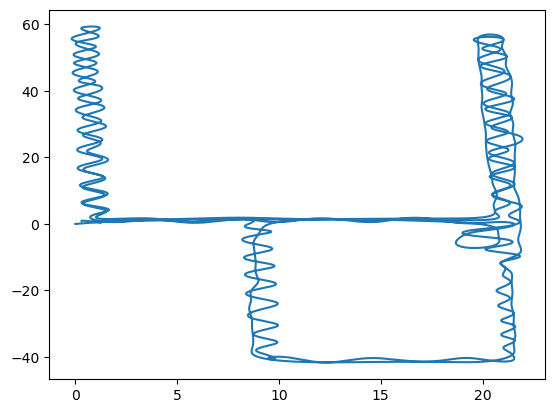

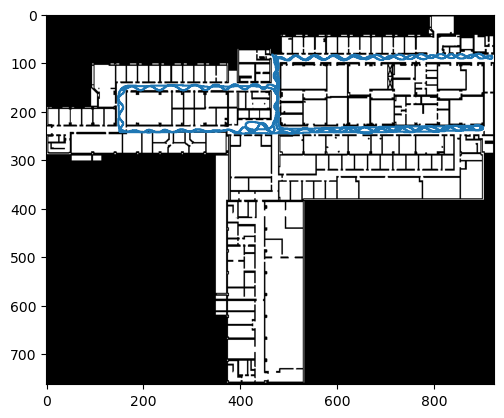

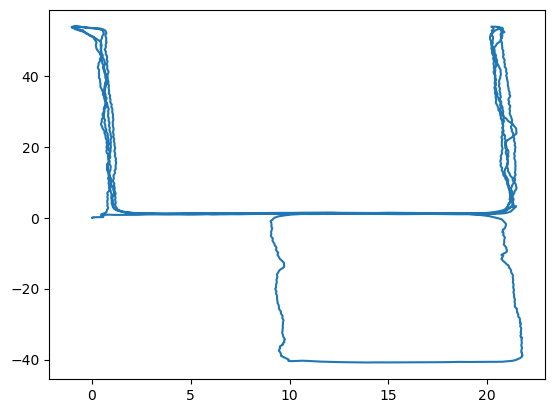

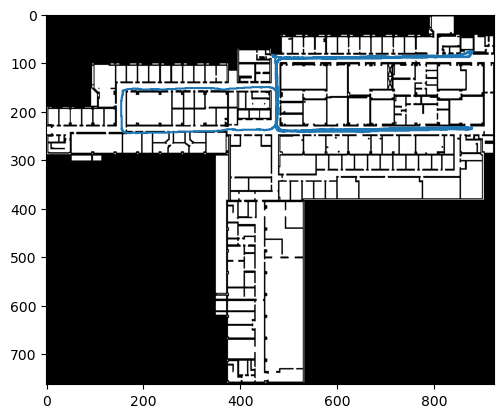

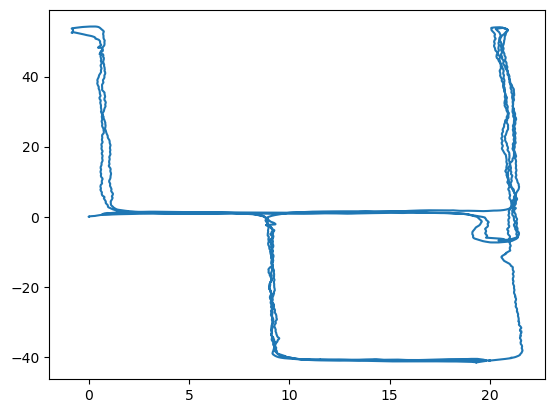

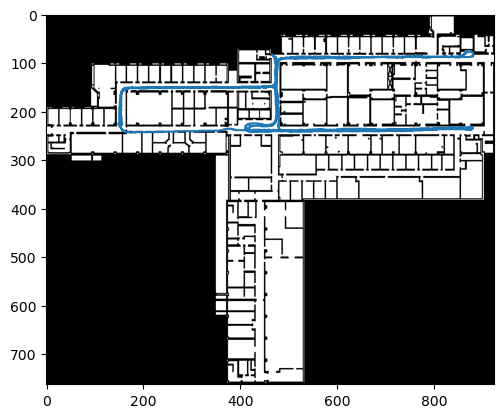

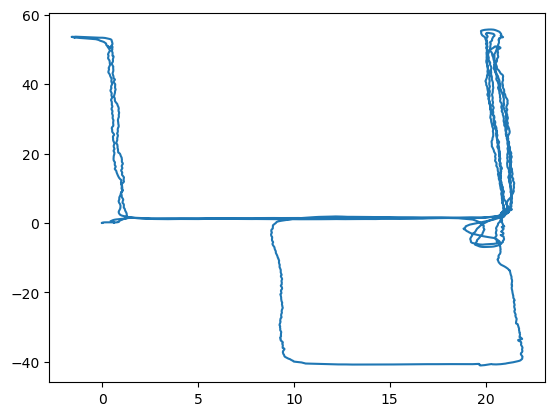

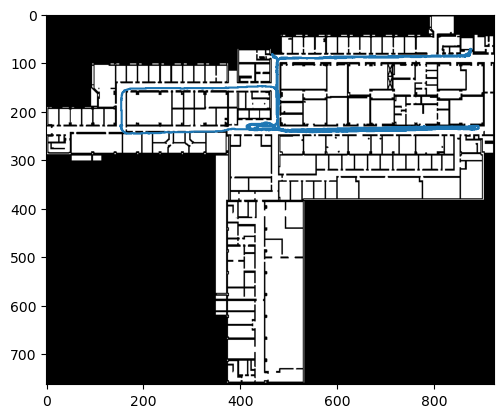

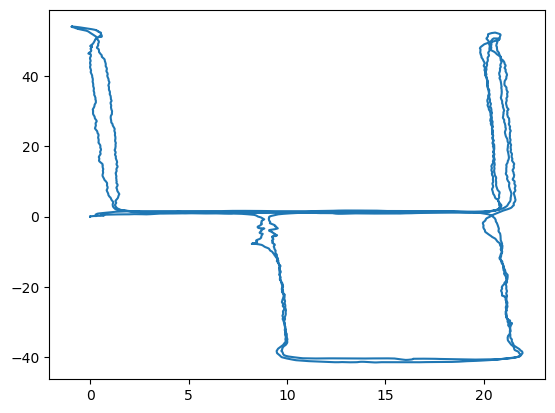

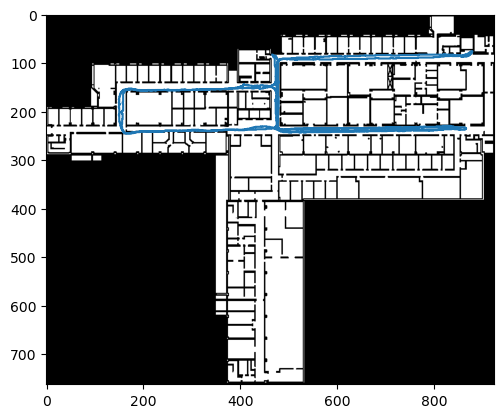

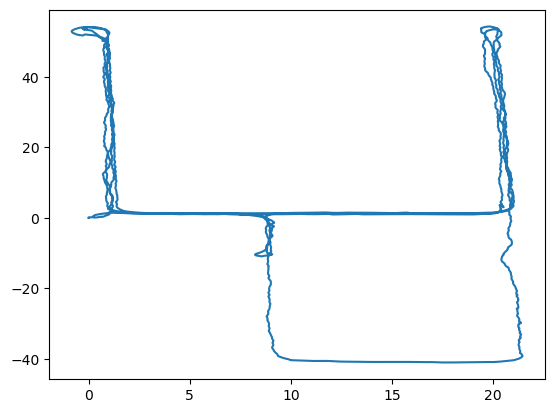

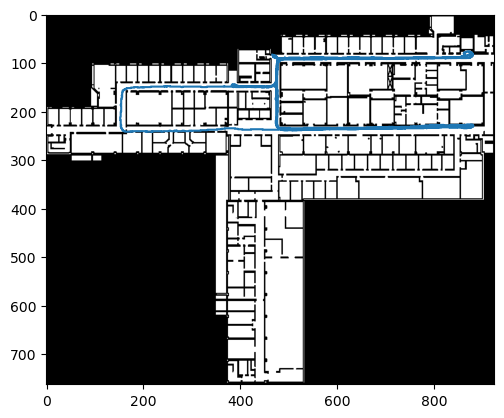

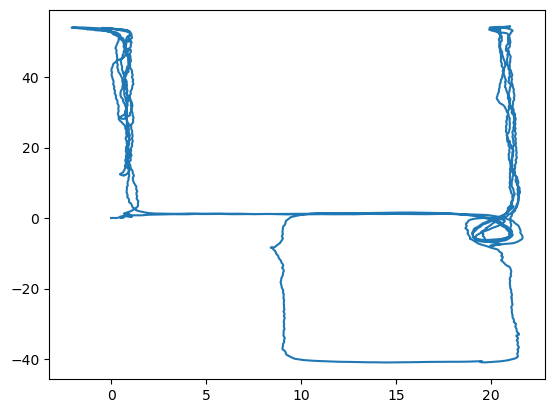

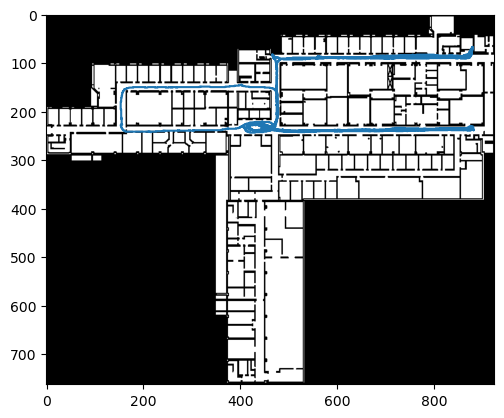

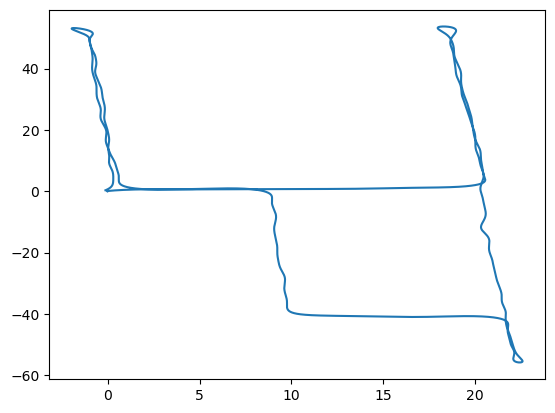

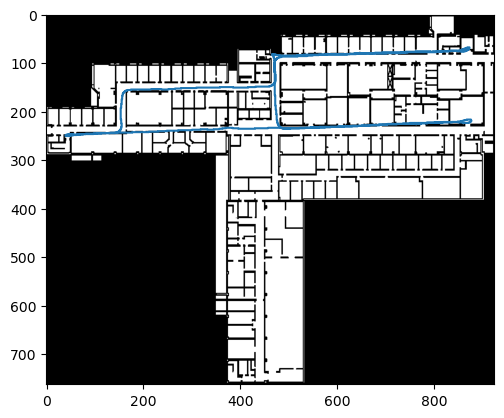

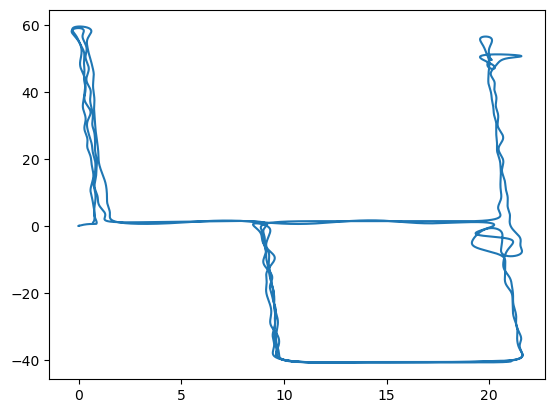

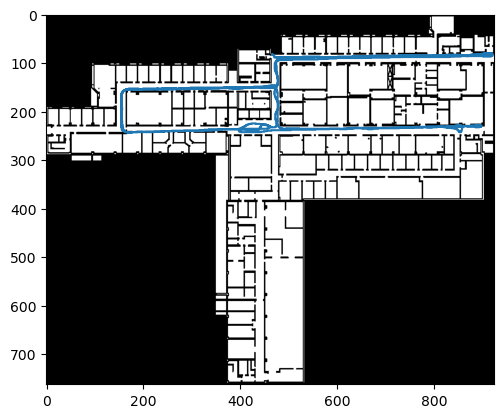

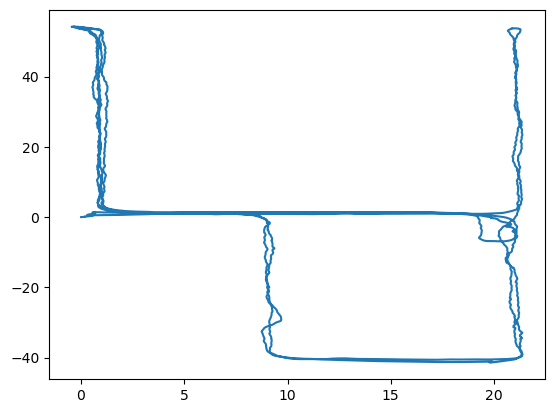

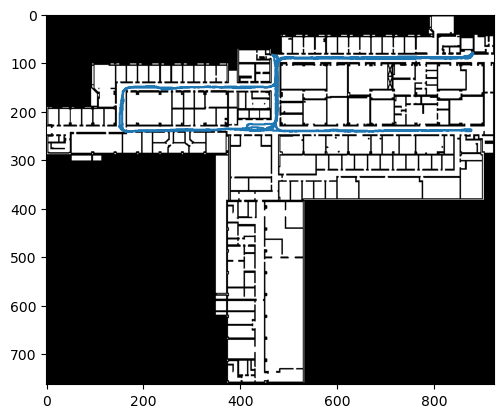

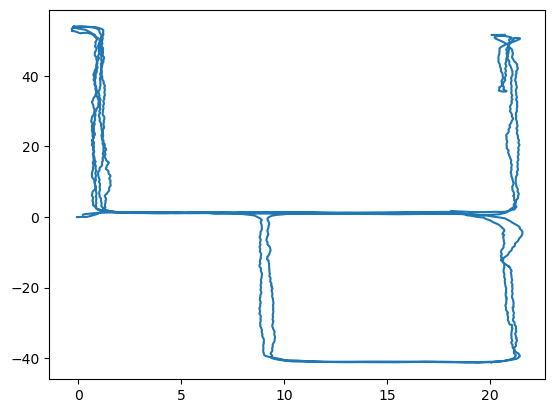

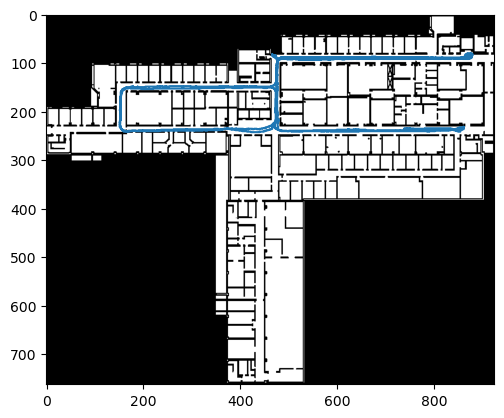

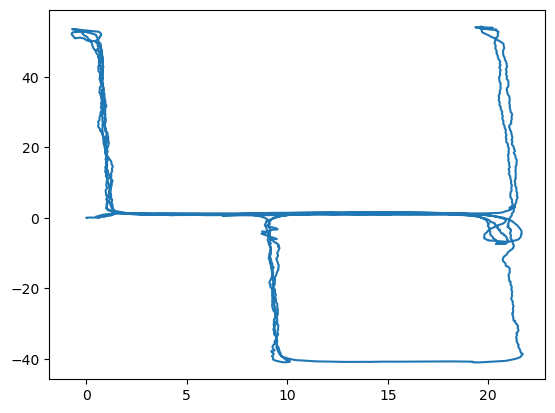

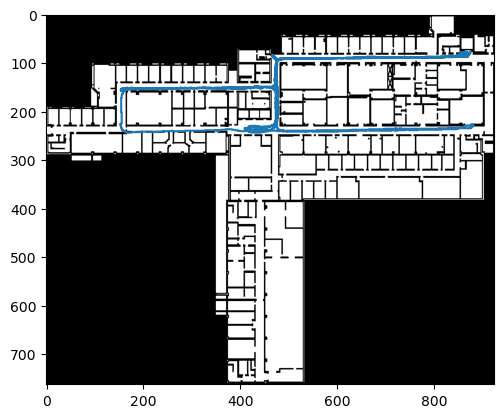

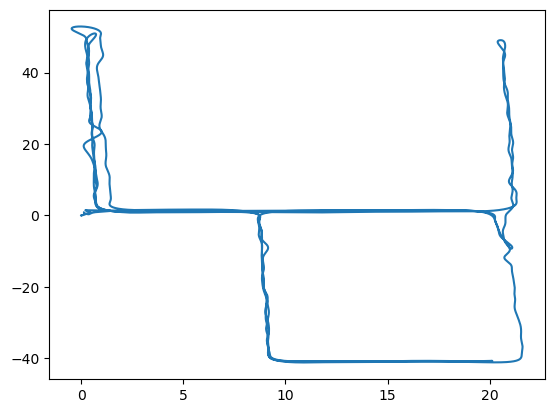

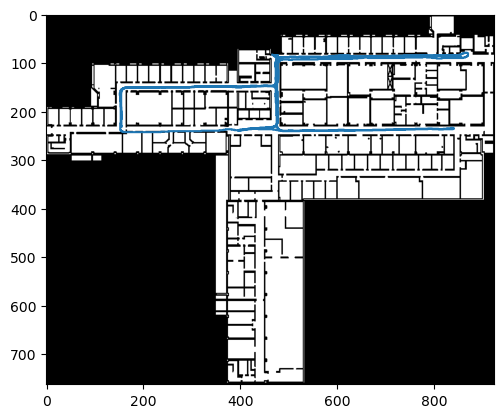

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import image
import os
from scipy import ndimage


def get_map(filename):
    im = image.imread(filename).T

    thresh = 0.99
    im[im < thresh] = 0.
    im[im >= thresh] = 1.

    im = 1-im.astype(int)

    
    # # # crop up to the edges of the buildings
    while np.all(im[0, :] == 0):
        im = im[1:, :]
    while np.all(im[-1, :] == 0):
        im = im[:-1, :]
    while np.all(im[:, 0] == 0):
        im = im[:, 1:]
    while np.all(im[:, -1] == 0):
        im = im[:, :-1]

    im = 1-im

    # blacken everything outside the actual map
    for idx in range(im.shape[0]):
        for jdx in range(im.shape[1]):
            if im[idx, jdx] != 0:
                im[idx, jdx] = 0
            else:
                break
        for jdx in range(im.shape[1]-1, 0, -1):
            if im[idx, jdx] != 0:
                im[idx, jdx] = 0
            else:
                break

        # plt.imshow(im, cmap='gray')
        # plt.show()
    return im

def _coord_transform(world_coords_orig, map_name):
    if map_name == "building1":  # or map_name == 'building1_big':
        world_coords_new = world_coords_orig.copy()
        world_coords_new[:, 0] = -world_coords_orig[:, 0]
        world_coords_new[:, 1] = world_coords_orig[:, 1]
    elif map_name == "building3":
        world_coords_new = world_coords_orig.copy()
        world_coords_new[:, 1] = world_coords_orig[:, 0]
        world_coords_new[:, 0] = world_coords_orig[:, 1]
    elif map_name == "building2_f1":
        world_coords_new = world_coords_orig.copy()
        world_coords_new[:, 0] = world_coords_orig[:, 1]
        world_coords_new[:, 1] = world_coords_orig[:, 0]
    elif map_name == "building2_f2":
        world_coords_new = world_coords_orig.copy()
        world_coords_new[:, 0] = world_coords_orig[:, 1]
        world_coords_new[:, 1] = world_coords_orig[:, 0]
    return world_coords_new

def get_map_by_name(map_file):
    return get_map(map_file)

def _world_to_image_coords(world_coords, map_size, world_size, origin):
    true_x_size = world_size[0]  # m
    true_y_size = world_size[1]  # m
    world_origin_offset_x = origin[0]  # m from top left corner of map
    world_origin_offset_y = origin[1]  # m from top left corner of map
    scale_factor_x = true_x_size/map_size[0]  # m/pixel
    scale_factor_y = true_y_size/map_size[1]  # m/pixel

    image_coord_x = np.round(
        (world_coords[:, 0] + world_origin_offset_x)/scale_factor_x).astype(int)
    image_coord_y = np.round(
        (world_coords[:, 1] + world_origin_offset_y)/scale_factor_y).astype(int)
    image_coords = np.hstack([image_coord_x[:, None], image_coord_y[:, None]])
    return image_coords



def world_to_image_coords(world_coords, map_name):
    return _world_to_image_coords(_coord_transform(world_coords, map_name), _map_sizes[map_name], _world_sizes[map_name], _origins[map_name])

files = os.listdir('./../data/datasets/idol/building3/known/')
map_file = "./../data/datasets/idol/building3.png"
map_name = 'building3'
_map_sizes = {
    "building3":  get_map_by_name(map_file).shape,
    "building2_f1":   get_map_by_name(map_file).shape,
    "building2_f2":   get_map_by_name(map_file).shape,
    "building1": get_map_by_name(map_file).shape,
}

_world_sizes = {
    "building3":  (121,    102.5),
    "building2_f1":   (69., 51),
     "building2_f2":   (69, 54.),#"building2_f2":   (69., 54.),
    "building1": (54, 18),
}

_origins = {  # world frame
    "building3":  (60.960, 10.973),
    "building2_f1":   (26.5,   34.5),
     "building2_f2":   (22.5,   22.1),#"building2_f2":   (22.6,   22.1),
    "building1": (14.023, 5.2),
}
# theta = 0.2822
theta = 1.8510
for file in files:
    file_name = "./../data/datasets/idol/building3/known/" + str(file) 
    # file_name = "./../data/datasets/idol_dataset/building1/train/10.feather"
    
    df = pd.read_feather(file_name)
    # positions = df[['processedPosX', 'processedPosY']].values
    x = df['processedPosX']*np.cos(theta) - df['processedPosY']*np.sin(theta)
    y = df['processedPosX']*np.sin(theta) + df['processedPosY']*np.cos(theta)
    positions = np.stack([x, y], axis=1)
    # plt.plot(positions)
    # plt.show()
    plt.plot(positions[:, 0], positions[:, 1])
    plt.show()

    img = get_map_by_name(map_file)
    map = ndimage.binary_dilation(get_map_by_name(map_file))
    # plt.imshow(map.T, cmap='gray')
    # plt.show()
    # plt.imshow(img, cmap='gray')
    # plt.show()
    
    new_coor = world_to_image_coords(positions, map_name)
    # plt.plot(positions[:, 0], positions[:, 1])
    # plt.show()
    
    plt.imshow(img.T, cmap='gray')
    plt.plot(new_coor[:, 0], new_coor[:, 1])
    plt.show()

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import image
import os
from scipy import ndimage
from pathlib import Path
from PIL import Image 
from scipy.ndimage import gaussian_filter, gaussian_filter1d, distance_transform_edt, rotate, affine_transform
import yaml
from utils import *
def process_map(map_array, resolution=0.05):
    """
    Converts a raw binary map into a normalized distance map after Gaussian smoothing.
    Input: map_tensor [1, H, W]
    Output: processed map [1, H, W]
    """
    processed_map = apply_gaussian_smoothing_then_threshold(map_array, sigma=1.0, thresh=0.6)
    processed_map = apply_opening_then_closing(processed_map, 2)

    distance_map = distance_transform_edt(processed_map)
    distance_map = distance_map * resolution
    #distance_map = 1 - (distance_map / distance_map.max())
    # distance_map = distance_map / distance_map.max()
    return distance_map
        
def load_idol_map(yaml_path, fixed_size=(64, 64)):
    with open(yaml_path, 'r') as f:
        metadata = yaml.safe_load(f)

    png_path = metadata['image']
    origin = np.array(metadata['origin'])
    free_thresh = metadata['free_thresh']
    world_size = metadata['world_size']
    map_name = metadata['map_name']

    # Load image and normalize
    # Load PGM using PIL
    # img = Image.open(png_path)
    # img = np.array(img).astype(np.float32).T
    img = image.imread(png_path).T
    if img is None:
        raise FileNotFoundError(f"Map image not found: {png_path}")

    img[img < free_thresh] = 0.
    img[img >= free_thresh] = 1.

    img = 1-img.astype(int)

    # print(np.all(img[0, :] == 0))
    # crop up to the edges of the buildings
    while np.all(img[0, :] == 0):
        img = img[1:, :]
    while np.all(img[-1, :] == 0):
        img = img[:-1, :]
    while np.all(img[:, 0] == 0):
        img = img[:, 1:]
    while np.all(img[:, -1] == 0):
        img = img[:, :-1]

    img = 1-img

    # blacken everything outside the actual map
    for idx in range(img.shape[0]):
        for jdx in range(img.shape[1]):
            if img[idx, jdx] != 0:
                img[idx, jdx] = 0
            else:
                break
        for jdx in range(img.shape[1]-1, 0, -1):
            if img[idx, jdx] != 0:
                img[idx, jdx] = 0
            else:
                break

    resolution = (world_size/np.array(img.shape)).mean()
    dist_map = process_map(img, resolution)
    original_size = dist_map.shape
    resized_map = Image.fromarray(dist_map).resize(fixed_size[::-1], Image.BILINEAR)
    resized_map = np.array(resized_map, dtype=np.float32)

    # plt.imshow(resized_map, cmap='gray')
    # plt.show()

    # Adjust origin proportionally to new size
    scale_x = fixed_size[1] / original_size[1]
    scale_y = fixed_size[0] / original_size[0]
    new_origin = origin.copy()
    new_origin[0] *= scale_x
    new_origin[1] *= scale_y
    meta_info = {
        'resolution': resolution,
        'origin': new_origin,
        'original_origin': origin,
        'original_shape': original_size,
        'free_thresh': free_thresh,
        'scale_x': scale_x,
        'scale_y': scale_y,
        'world_size': world_size,
        'map_name': map_name
    }
    return resized_map, meta_info

data_dir = Path('./../data/datasets/idol_dataset/')
for file in sorted(data_dir.iterdir()):
    if file.suffix == '.yaml':
        print(file)
        map_array, meta_info = load_idol_map(file)
        # plt.imshow(map_array.T)
        # plt.show()


../data/datasets/idol_dataset/building1_0.yaml
../data/datasets/idol_dataset/building1_1.yaml
../data/datasets/idol_dataset/building1_10.yaml
../data/datasets/idol_dataset/building1_11.yaml
../data/datasets/idol_dataset/building1_12.yaml
../data/datasets/idol_dataset/building1_13.yaml
../data/datasets/idol_dataset/building1_14.yaml
../data/datasets/idol_dataset/building1_15.yaml
../data/datasets/idol_dataset/building1_16.yaml
../data/datasets/idol_dataset/building1_17.yaml
../data/datasets/idol_dataset/building1_18.yaml
../data/datasets/idol_dataset/building1_19.yaml
../data/datasets/idol_dataset/building1_2.yaml
../data/datasets/idol_dataset/building1_20.yaml
../data/datasets/idol_dataset/building1_21.yaml
../data/datasets/idol_dataset/building1_22.yaml
../data/datasets/idol_dataset/building1_23.yaml
../data/datasets/idol_dataset/building1_24.yaml
../data/datasets/idol_dataset/building1_25.yaml
../data/datasets/idol_dataset/building1_26.yaml
../data/datasets/idol_dataset/building1_27.

In [17]:
data_dir = os.listdir('./../data/datasets/idol/')
print(data_dir)
d for d in data_dir

['building3.png', '.ipynb_checkpoints', 'building1', 'building3', 'building2_f2_test.png', 'building1.png', 'building2.png', 'building2', 'building1_map_more_tables.png']


In [86]:
#!/usr/bin/env python3
from pathlib import Path
import shutil

# ----- configure ------------------------------------------------------------
SRC_ROOT   = Path("./../data/datasets/idol/")          # contains building1/, building2/, …
DEST_ROOT  = Path("./../data/datasets/idol_dataset/")  # will hold all renamed files
MOVE_FILES = False                          # True → move, False → copy
# -------------------------------------------------------------------------- #

DEST_ROOT.mkdir(parents=True, exist_ok=True)

known_names, unknown_names = [], []
next_idx = {}                               # keeps per-building counter

# ---------- 1) DATA FILES --------------------------------------------------- #
for bdir in sorted(SRC_ROOT.glob("building[0-9]*")):          # building1, building2 …
    building = bdir.name
    counter  = 0

    for label in ("known", "unknown"):
        sdir = bdir / label
        if not sdir.is_dir():
            continue

        for src in sorted(sdir.iterdir()):                    # file 0.*, 1.*, …
            if src.is_dir():
                continue

            new_name = f"{building}_{counter}{src.suffix}"
            dest     = DEST_ROOT / new_name
            new_img_name = f"{building}_{counter}.png"
            img_dest     = DEST_ROOT / new_img_name
            img_name = f"{building}.png"
            img = SRC_ROOT / img_name
            shutil.move(src, dest) if MOVE_FILES else shutil.copy2(src, dest)
            shutil.move(img, img_dest) if MOVE_FILES else shutil.copy2(img, img_dest)

            (known_names if label == "known" else unknown_names).append(new_name[:-8])
            counter += 1

    next_idx[building] = counter              # remember where we stopped

# ---------- 2) PNG IMAGES --------------------------------------------------- #
# for img in SRC_ROOT.glob("building[0-9]*.png"):               # building1.png …
#     building = img.stem                     # "building1"
#     counter  = next_idx.get(building, 0)    # 0 if building had no data files
#     new_name = f"{building}_{counter}.png"
#     dest     = DEST_ROOT / new_name
#     shutil.move(img, dest) if MOVE_FILES else shutil.copy2(img, dest)

# # ---------- 3) MANIFESTS ---------------------------------------------------- #
(DEST_ROOT / "known.txt"   ).write_text("\n".join(known_names)   + "\n")
(DEST_ROOT / "unknown.txt" ).write_text("\n".join(unknown_names) + "\n")

print(f"Finished.\n  ↳ {len(known_names)} known files\n  ↳ {len(unknown_names)} unknown files\n"
      f"  ↳ {len(list(SRC_ROOT.glob('building[0-9]*.png')))} images processed")

# --------------------------------------------------------------------------- #
#  YAML-generation for each map image
# --------------------------------------------------------------------------- #
#
# Required pip packages:
#   pip install pillow pyyaml
#
from PIL import Image
import yaml

# --------------------------------------------------------------------------- #
#  PARAMETERS you must fill in once
# --------------------------------------------------------------------------- #
FREE_THRESH         = 0.99         # example: probability below this = free
ORIGIN_BY_BUILDING  = {           # metres ↙ bottom-left corner in world coords
    "building1": [14.023, 5.2],
    "building2": [22.5,   22.1],
    "building3": [60.960, 10.973],
}
WORLD_SIZE_BY_BUILDING  = {           # metres ↙ bottom-left corner in world coords
    "building1": [54, 18],
    "building2": [69., 54.],
    "building3": [121,    102.5],
}

#------------------------------------------------------- #

for png_path in DEST_ROOT.glob("building*_*.png"):
    building   = png_path.stem.split("_")[0]          # "building1"
    origin_xy  = ORIGIN_BY_BUILDING.get(building)
    world_size  = WORLD_SIZE_BY_BUILDING.get(building)

    # --- compute world-size from image dimensions -------------------------- #
    # w_px, h_px = Image.open(png_path).size            # (width, height) in px
    # world_size = [w_px * RESOLUTION_M_PER_PX,
    #               h_px * RESOLUTION_M_PER_PX]         # [x, y] in metres

    yaml_data = {
        "image": str(png_path.resolve()),
        "world_size": world_size,                     # [x, y]
        "origin": origin_xy,                          # [x_o, y_o]
        "free_thresh": FREE_THRESH,                # thresh
        "map_name": building
    }

    yaml_path = png_path.with_suffix(".yaml")
    def _represent_list_flow(dumper, data):
        return dumper.represent_sequence("tag:yaml.org,2002:seq", data, flow_style=True)

    yaml.SafeDumper.add_representer(list, _represent_list_flow)

    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(yaml_data, f, sort_keys=False)

    print(f"YAML created → {yaml_path.name}")

Finished.
  ↳ 94 known files
  ↳ 36 unknown files
  ↳ 3 images processed
YAML created → building3_28.yaml
YAML created → building3_26.yaml
YAML created → building1_15.yaml
YAML created → building1_35.yaml
YAML created → building3_21.yaml
YAML created → building1_10.yaml
YAML created → building3_19.yaml
YAML created → building1_30.yaml
YAML created → building3_20.yaml
YAML created → building1_69.yaml
YAML created → building2_16.yaml
YAML created → building1_37.yaml
YAML created → building1_66.yaml
YAML created → building1_52.yaml
YAML created → building1_22.yaml
YAML created → building3_16.yaml
YAML created → building1_8.yaml
YAML created → building1_51.yaml
YAML created → building3_27.yaml
YAML created → building1_64.yaml
YAML created → building1_71.yaml
YAML created → building3_14.yaml
YAML created → building2_9.yaml
YAML created → building1_16.yaml
YAML created → building1_0.yaml
YAML created → building1_26.yaml
YAML created → building1_27.yaml
YAML created → building3_7.yaml
YAML cr

In [8]:
# --------------------------------------------------------------------------- #
#  YAML-generation for each map image
# --------------------------------------------------------------------------- #
#
# Required pip packages:
#   pip install pillow pyyaml
#
from PIL import Image
import yaml

# --------------------------------------------------------------------------- #
#  PARAMETERS you must fill in once
# --------------------------------------------------------------------------- #
FREE_THRESH         = 0.2         # example: probability below this = free
ORIGIN_BY_BUILDING  = {           # metres ↙ bottom-left corner in world coords
    "building1": [0.0, 0.0],
    "building2": [0.0, 0.0],
    "building3": [0.0, 0.0],
}
WORLD_SIZE_BY_BUILDING  = {           # metres ↙ bottom-left corner in world coords
    "building1": [1.0, 0.0],
    "building2": [2.0, 0.0],
    "building3": [3.0, 0.0],
}
# --------------------------------------------------------------------------- #

for png_path in DEST_ROOT.glob("building*_*.png"):
    building   = png_path.stem.split("_")[0]          # "building1"
    origin_xy  = ORIGIN_BY_BUILDING.get(building)
    world_size  = WORLD_SIZE_BY_BUILDING.get(building)

    # --- compute world-size from image dimensions -------------------------- #
    # w_px, h_px = Image.open(png_path).size            # (width, height) in px
    # world_size = [w_px * RESOLUTION_M_PER_PX,
    #               h_px * RESOLUTION_M_PER_PX]         # [x, y] in metres

    yaml_data = {
        "image": str(png_path.resolve()),
        "world_size": world_size,                     # [x, y]
        "origin": origin_xy,                          # [x_o, y_o]
        "free_threshold": FREE_THRESH,                # thresh
    }

    yaml_path = png_path.with_suffix(".yaml")
    def _represent_list_flow(dumper, data):
        return dumper.represent_sequence("tag:yaml.org,2002:seq", data, flow_style=True)

    yaml.SafeDumper.add_representer(list, _represent_list_flow)

    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(yaml_data, f, sort_keys=False)

    print(f"YAML created → {yaml_path.name}")


YAML created → building3_25.yaml
YAML created → building1_16.yaml
YAML created → building2_10.yaml
YAML created → building1_18.yaml
YAML created → building2_8.yaml
YAML created → building2_18.yaml
YAML created → building1_8.yaml
YAML created → building1_10.yaml
YAML created → building1_25.yaml
YAML created → building2_13.yaml
YAML created → building2_22.yaml
YAML created → building2_26.yaml
YAML created → building2_5.yaml
YAML created → building3_12.yaml
YAML created → building3_29.yaml
YAML created → building3_20.yaml
YAML created → building2_4.yaml
YAML created → building1_3.yaml
YAML created → building3_9.yaml
YAML created → building2_16.yaml
YAML created → building1_7.yaml
YAML created → building3_28.yaml
YAML created → building2_19.yaml
YAML created → building1_6.yaml
YAML created → building2_1.yaml
YAML created → building1_28.yaml
YAML created → building1_5.yaml
YAML created → building2_23.yaml
YAML created → building3_4.yaml
YAML created → building3_11.yaml
YAML created → buildi